## Cell-type composition prediction and label simulation

### Empirical local cell-type probability vector

Let $C_i\in\{1,\ldots,K_C\}$ denote the observed cell-type annotation. The cell-type notebook first constructs an empirical local composition vector from the observed cell-type labels. This calculation is performed separately within each slice.

For a cell $i$ in slice $b$, let

$$
\boldsymbol{v}_i=(x_i,y_i)^\top
$$

be the first two dimensions of `adata.obsm["spatial_3d"]`. A 9-nearest-neighbor query (not including itself) is fitted within slice $b$. Let $d_{i}$ denote the last distance returned by this 9-neighbor query. The slice-specific radius is

$$
\rho_b
=
\frac{1}{n_b}
\sum_{i:\,b_i=b}d_{i},
$$

where $n_b$ is the number of cells in slice $b$. The radius neighborhood of cell $i$ is then defined as

$$
\mathcal{N}_i
=
\left\{
 j:b_j=b_i,\ \|\boldsymbol{v}_j-\boldsymbol{v}_i\|_2\leq\rho_{b_i}
\right\}.
$$

The cell $i$ itself belongs to $\mathcal{N}_i$. For cell type $c$, the empirical local probability is

$$
\pi_{ic}
=
\frac{1}{|\mathcal{N}_i|}
\sum_{j\in\mathcal{N}_i}
\mathbf{1}\{C_j=c\},
\qquad c=1,\ldots,K_C.
$$

Hence,

$$
\boldsymbol{\pi}_i
=
(\pi_{i1},\ldots,\pi_{iK_C})^\top,
\qquad
\pi_{ic}\geq0,
\qquad
\sum_{c=1}^{K_C}\pi_{ic}=1.
$$

In the code, these quantities form the columns `prob_<cell type>` of `prob_df`. They are computed directly from the observed `cell_type` labels and serve as continuous multivariate training targets.

### Region-relative three-dimensional coordinates

The network does not use the raw coordinates directly. Instead, it constructs a region-relative coordinate representation from the predicted domains $\widehat D_i$.

For each predicted region $d$, collect the three-dimensional coordinates of all cells satisfying $\widehat D_i=d$. If the region contains at least four cells, a three-component PCA is fitted to the coordinates in that region. Let

$$
\boldsymbol{a}_i^{(d)}
=
(a_{i1}^{(d)},a_{i2}^{(d)},a_{i3}^{(d)})^\top
$$

denote the resulting PCA score. If the region contains fewer than four cells, the original three-dimensional coordinate is used in place of the PCA score.

Each component is then rescaled within its predicted region to the interval $[-1,1]$:

$$
r_{iq}
=
2\frac{a_{iq}^{(d)}-a_{q,\min}^{(d)}}
{a_{q,\max}^{(d)}-a_{q,\min}^{(d)}}-1,
\qquad q=1,2,3,
$$

for cells with $\widehat D_i=d$. If the component range is smaller than $10^{-6}$, the denominator is replaced by 1. The resulting vector

$$
\boldsymbol{r}_i=(r_{i1},r_{i2},r_{i3})^\top
$$

is stored in `adata.obsm["XYZ_rel_pca_global"]`. The PCA and min--max transformation are performed separately for each predicted region, using all cells assigned to that region across the dataset.

### Probability-regression network

Let $\boldsymbol{e}(\widehat D_i)\in\{0,1\}^{K_D}$ denote the one-hot encoding of the predicted region. The actual neural-network input is

$$
\boldsymbol{H}_i
=
\left[
\boldsymbol{r}_i^\top,
\boldsymbol{e}(\widehat D_i)^\top
\right]^\top.
$$

The empirical local probability vector $\boldsymbol{\pi}_i$ is not included in $\boldsymbol{H}_i$. It is the response that the network is trained to reconstruct.

The network has layer widths

$$
(3+K_D)\longrightarrow256\longrightarrow128\longrightarrow K_C.
$$

The first two linear layers are each followed by a ReLU activation and batch normalization. Let $g_c(\boldsymbol{H}_i;\boldsymbol{\theta}_C)$ denote the final logit for cell type $c$. The fitted local composition is

$$
\widehat\pi_{ic}
=
\frac{\exp\{g_c(\boldsymbol{H}_i;\boldsymbol{\theta}_C)\}}
{\sum_{c'=1}^{K_C}\exp\{g_{c'}(\boldsymbol{H}_i;\boldsymbol{\theta}_C)\}},
\qquad c=1,\ldots,K_C.
$$

The model is trained by minimizing the mean squared error between the predicted and empirical local probability vectors,

$$
\mathcal{L}_C(\boldsymbol{\theta}_C)
=
\frac{1}{nK_C}
\sum_{i=1}^{n}
\sum_{c=1}^{K_C}
\left(\widehat\pi_{ic}-\pi_{ic}\right)^2.
$$

Thus, this module is a probability-vector regression model, not a conventional classifier trained by cross-entropy on the individual labels $C_i$. The code uses all observations for training, without a train--validation split. It uses the Adam optimizer with learning rate $10^{-3}$, batch size 1024, and 300 epochs. No explicit NumPy or PyTorch seed is set in the cell-type notebook before network initialization and training.

After training, the matrix of fitted probability vectors is stored as `Y_pred_all`. A simulated cell-type label is then generated independently for each cell, conditional on its fitted probability vector:

$$
\widehat C_i
\sim
\operatorname{Categorical}
\left(
\widehat\pi_{i1},\ldots,\widehat\pi_{iK_C}
\right).
$$

The categorical sampling uses `numpy.random.default_rng(42)`, and the sampled labels are stored in `adata.obs["pred_celltype"]`.

In [1]:
import numpy as np
import pandas as pd
import anndata as ad
import scanpy as sc
import matplotlib.pyplot as plt

adata = sc.read('../adata_backup_with_pred_region.h5ad')
adata

AnnData object with n_obs × n_vars = 64373 × 155
    obs: 'Animal_ID', 'Animal_sex', 'Behavior', 'Bregma', 'Centroid_X', 'Centroid_Y', 'Cell_class', 'Neuron_cluster_ID', 'slices', 'Coord_X', 'Coord_Y', 'x', 'y', 'z', 'cell_type', 'batch', 'n_genes', 'size', 'STAIR', 'pred_region'
    var: 'n_cells'
    uns: 'batch_colors', 'cell_type_colors', 'log1p'
    obsm: 'STAIR', 'STAIR_clean', 'latent', 'spatial', 'spatial_2d_raw', 'spatial_2d_raw_rotate', 'spatial_2d_μm', 'spatial_2d_μm_rotate', 'spatial_3d', 'spatial_3d_raw', 'spatial_3d_raw_rotate', 'spatial_3d_μm', 'spatial_3d_μm_rotate'
    layers: 'Denoise', 'counts', 'noise1', 'noise2', 'noise3', 'noise4'

In [2]:
import numpy as np
import numpy as np
import pandas as pd
from sklearn.neighbors import KDTree
from sklearn.neighbors import NearestNeighbors

spatial_key = "spatial_3d"
region_key = "pred_region"

celltype_list = sorted(adata.obs["cell_type"].unique())
celltype_to_idx = {ct: i for i, ct in enumerate(celltype_list)}

all_prob_list = []

# ===============================
# Compute slice by slice
# ===============================
for batch in adata.obs["batch"].unique():

    adata_slice = adata[adata.obs["batch"] == batch].copy()

    coords = adata_slice.obsm[spatial_key][:, :2]
    cell_types = adata_slice.obs["cell_type"].values

    # ===== Automatically determine the radius based on an average of 9 neighbors =====
    nbrs = NearestNeighbors(n_neighbors=10).fit(coords)
    distances, _ = nbrs.kneighbors(coords)
    radius = distances[:, -1].mean()

    print(f"{batch} | radius = {radius:.2f}")

    tree = KDTree(coords)

    prob_mat = np.zeros((adata_slice.n_obs, len(celltype_list)))

    for i in range(adata_slice.n_obs):

        ind = tree.query_radius(
            coords[i].reshape(1, -1),
            r=radius
        )[0]

        neigh_types = cell_types[ind]

        for ct in neigh_types:
            prob_mat[i, celltype_to_idx[ct]] += 1

        prob_mat[i] /= prob_mat[i].sum()

    prob_slice = pd.DataFrame(
        prob_mat,
        index=adata_slice.obs_names,
        columns=[f"prob_{ct}" for ct in celltype_list]
    )

    prob_slice["batch"] = batch

    all_prob_list.append(prob_slice)

# ===============================
# Combine all slices
# ===============================
prob_df = pd.concat(all_prob_list)

print(prob_df.shape)


A0 | radius = 43.99
A1 | radius = 43.85
A2 | radius = 41.88
A3 | radius = 42.43
A4 | radius = 41.16
A5 | radius = 40.64
A6 | radius = 40.86
A7 | radius = 40.10
A8 | radius = 39.45
A9 | radius = 39.69
A10 | radius = 41.01
A11 | radius = 40.74
(64373, 10)


In [3]:
from sklearn.decomposition import PCA

XYZ_full = adata.obsm[spatial_key][:, :3]
XYZ_rel_pca = np.zeros_like(XYZ_full, dtype=float)
regions = adata.obs[region_key].values
region_coordinate_transforms = {}

for r in np.unique(regions):
    idx_region = regions == r
    region_indices = np.where(idx_region)[0]
    XYZ_r = XYZ_full[region_indices]

    if XYZ_r.shape[0] < 4:
        pca = None
        XYZ_proj = XYZ_r.copy()
    else:
        pca = PCA(n_components=3).fit(XYZ_r)
        XYZ_proj = pca.transform(XYZ_r)

    min_xyz = XYZ_proj.min(axis=0)
    scale = XYZ_proj.max(axis=0) - min_xyz
    scale[scale < 1e-6] = 1.0
    XYZ_rel_pca[region_indices] = 2 * (XYZ_proj - min_xyz) / scale - 1

    # Required if the trained cell-type model is later applied to new coordinates.
    region_coordinate_transforms[str(r)] = {
        "pca": pca,
        "min_xyz": min_xyz,
        "scale": scale
    }

adata.obsm["XYZ_rel_pca_global"] = XYZ_rel_pca


In [4]:
import numpy as np
import pandas as pd

# -------------------------
# Full dataset
# -------------------------
prob_all = prob_df.loc[adata.obs_names].copy()

# -------------------------
# Relative coordinates based on 3D PCA
# -------------------------
XYZ_all = adata.obsm["XYZ_rel_pca_global"]

# -------------------------
# Region one-hot encoding with fixed categories over the full dataset
# -------------------------
# adata.obs["STAIR"] = adata.obs["STAIR"].astype("category")
# stair_categories = adata.obs["STAIR"].cat.categories

# stair_onehot_all = pd.get_dummies(
#     adata.obs["STAIR"]
# ).reindex(columns=stair_categories)
adata.obs[region_key] = adata.obs[region_key].astype("category")
region_categories = adata.obs[region_key].cat.categories

region_onehot_all = pd.get_dummies(
    adata.obs[region_key]
).reindex(columns=region_categories)

# -------------------------
# Concatenate input features
# -------------------------
# X_all = np.concatenate(
#     [XYZ_all, stair_onehot_all.values],
#     axis=1
# )
X_all = np.concatenate(
    [XYZ_all, region_onehot_all.values],
    axis=1
)

# -------------------------
# Output
# -------------------------
prob_cols = [c for c in prob_all.columns if c.startswith("prob_")]
Y_all = prob_all[prob_cols].values

print("X_all:", X_all.shape)
print("Y_all:", Y_all.shape)

X_all: (64373, 16)
Y_all: (64373, 9)


In [5]:
import torch
import torch.nn as nn

class SpatialProbMLP(nn.Module):
    def __init__(self, input_dim, n_celltypes):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 256),
            nn.ReLU(),
            nn.BatchNorm1d(256),

            nn.Linear(256, 128),
            nn.ReLU(),
            nn.BatchNorm1d(128),

            nn.Linear(128, n_celltypes)
        )

    def forward(self, x):
        logits = self.net(x)
        return torch.softmax(logits, dim=1)

In [6]:
from torch.utils.data import Dataset, DataLoader



class SpatialDataset(Dataset):
    def __init__(self, X, Y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.Y = torch.tensor(Y, dtype=torch.float32)

    def __len__(self):
        return self.X.shape[0]

    def __getitem__(self, idx):
        return self.X[idx], self.Y[idx]


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

dataset = SpatialDataset(X_all, Y_all)
loader = DataLoader(dataset, batch_size=1024, shuffle=True)

model = SpatialProbMLP(
    input_dim=X_all.shape[1],
    n_celltypes=Y_all.shape[1]
).to(device)

criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)


max_epochs = 300
print_every = 10

for epoch in range(max_epochs):

    model.train()
    total_loss = 0.0

    for Xb, Yb in loader:
        Xb = Xb.to(device)
        Yb = Yb.to(device)

        Pb = model(Xb)
        loss = criterion(Pb, Yb)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    avg_loss = total_loss / len(loader)

    if (epoch + 1) % print_every == 0 or epoch == 0:
        print(f"Epoch {epoch+1:04d} | Loss = {avg_loss:.6f}")

Epoch 0001 | Loss = 0.017631
Epoch 0010 | Loss = 0.010150
Epoch 0020 | Loss = 0.009634
Epoch 0030 | Loss = 0.009351
Epoch 0040 | Loss = 0.008987
Epoch 0050 | Loss = 0.008758
Epoch 0060 | Loss = 0.008586
Epoch 0070 | Loss = 0.008390
Epoch 0080 | Loss = 0.008311
Epoch 0090 | Loss = 0.008186
Epoch 0100 | Loss = 0.008113
Epoch 0110 | Loss = 0.008007
Epoch 0120 | Loss = 0.007972
Epoch 0130 | Loss = 0.007868
Epoch 0140 | Loss = 0.007861
Epoch 0150 | Loss = 0.007774
Epoch 0160 | Loss = 0.007746
Epoch 0170 | Loss = 0.007688
Epoch 0180 | Loss = 0.007664
Epoch 0190 | Loss = 0.007603
Epoch 0200 | Loss = 0.007543
Epoch 0210 | Loss = 0.007550
Epoch 0220 | Loss = 0.007540
Epoch 0230 | Loss = 0.007490
Epoch 0240 | Loss = 0.007458
Epoch 0250 | Loss = 0.007446
Epoch 0260 | Loss = 0.007390
Epoch 0270 | Loss = 0.007390
Epoch 0280 | Loss = 0.007331
Epoch 0290 | Loss = 0.007333
Epoch 0300 | Loss = 0.007345


In [7]:
model.eval()
with torch.no_grad():
    P_all = model(
        torch.tensor(X_all, dtype=torch.float32).to(device)
    ).cpu().numpy()

Y_pred_all = pd.DataFrame(
    P_all,
    index=adata.obs_names,
    columns=prob_cols
)

In [8]:
from pathlib import Path
import joblib

MODEL_DIR = Path("../saved_models")
MODEL_DIR.mkdir(parents=True, exist_ok=True)

# Save predicted probabilities in AnnData as well as the reusable model.
celltype_names = [c.replace("prob_", "") for c in prob_cols]
adata.obsm["pred_celltype_proba"] = P_all.astype(np.float32)
adata.uns["pred_celltype_names"] = np.asarray(celltype_names, dtype=str)

torch.save(
    {k: v.detach().cpu() for k, v in model.state_dict().items()},
    MODEL_DIR / "celltype_mlp_state.pt"
)
joblib.dump(
    {
        "input_dim": int(X_all.shape[1]),
        "n_celltypes": int(Y_all.shape[1]),
        "prob_cols": list(prob_cols),
        "region_categories": list(region_categories),
        "region_coordinate_transforms": region_coordinate_transforms,
        "spatial_key": spatial_key,
        "region_key": region_key
    },
    MODEL_DIR / "celltype_preprocess.joblib"
)
print("Saved cell-type model to", MODEL_DIR.resolve())


Saved cell-type model to /Users/yyq/Documents/MyDocuments/project/吴浩老师 3d ST simulator/code/20260525 志伟源代码+原始数据/saved_models


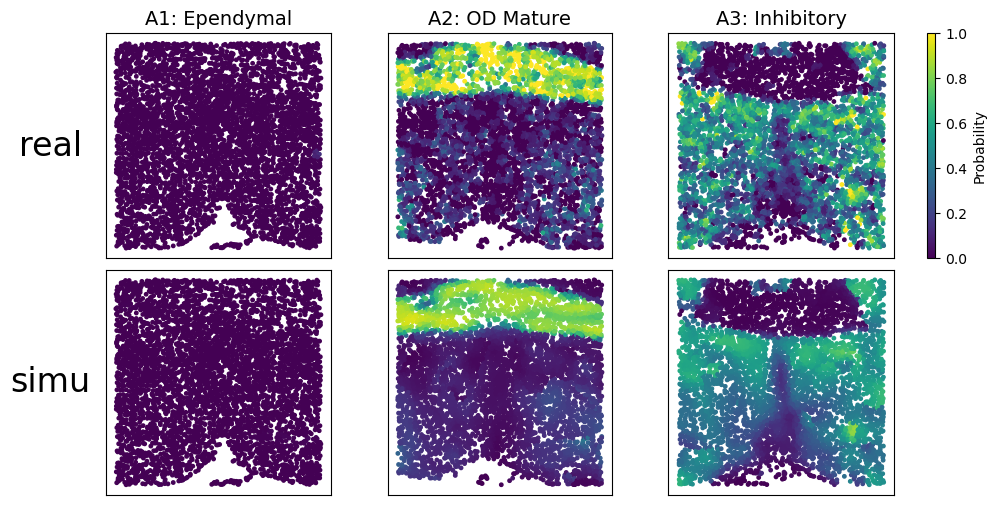

Saved: ./cell_type/prob_true_vs_pred_all_2.png


In [9]:
import os
import numpy as np
import matplotlib.pyplot as plt
# from matplotlib import font_manager

# font_cn = font_manager.FontProperties(
#     fname="/usr/share/fonts/opentype/noto/NotoSansCJK-Regular.ttc"
# )



out_dir = "./cell_type"
os.makedirs(out_dir, exist_ok=True)

# pairs = [
#     ("A6", "Ependymal"),
#     ("A1", "OD Mature"),
#     ("A11", "Inhibitory")
# ]
pairs = [
    ("A1", "Ependymal"),
    ("A2", "OD Mature"),
    ("A3", "Inhibitory")
]

# ----------------------------
# Use a common color range
# ----------------------------
all_true = []
all_pred = []

for slice_id, celltype in pairs:

    col = f"prob_{celltype}"

    adata_slice = adata[adata.obs["batch"] == slice_id]
    prob_slice = prob_df.loc[adata_slice.obs_names]

    all_true.append(prob_slice[col].values)
    all_pred.append(Y_pred_all.loc[adata_slice.obs_names, col].values)

vmin = min(np.min(np.concatenate(all_true)),
           np.min(np.concatenate(all_pred)))

vmax = max(np.max(np.concatenate(all_true)),
           np.max(np.concatenate(all_pred)))

# ----------------------------
# Create the figure layout
# ----------------------------
fig, axes = plt.subplots(
    2, 4,
    figsize=(11,6),
    gridspec_kw={"width_ratios":[1,1,1,0.03]}  # ⭐ 最后一列给 colorbar（窄）
)

axes_plot = axes[:, :3]
cbar_ax = axes[0,3]

# ----------------------------
# Plot
# ----------------------------
for i, (slice_id, celltype) in enumerate(pairs):

    col = f"prob_{celltype}"

    adata_slice = adata[adata.obs["batch"] == slice_id]
    prob_slice = prob_df.loc[adata_slice.obs_names]

    p_true = prob_slice[col].values
    p_pred = Y_pred_all.loc[adata_slice.obs_names, col].values

    XY = adata_slice.obsm[spatial_key][:,:2]
    x = XY[:,0]
    y = XY[:,1]

    # True
    sc = axes_plot[0,i].scatter(
        x, y,
        c=p_true,
        cmap="viridis",
        s=6,
        vmin=vmin,
        vmax=vmax
    )

    axes_plot[0,i].set_title(f"{slice_id}: {celltype}", fontsize=14)

    axes_plot[0,i].set_xticks([])
    axes_plot[0,i].set_yticks([])
    axes_plot[0,i].set_aspect("equal")

    # Pred
    axes_plot[1,i].scatter(
        x, y,
        c=p_pred,
        cmap="viridis",
        s=6,
        vmin=vmin,
        vmax=vmax
    )

    axes_plot[1,i].set_xticks([])
    axes_plot[1,i].set_yticks([])
    axes_plot[1,i].set_aspect("equal")

# ----------------------------
# Labels on the left
# ----------------------------
axes[0,0].set_ylabel("real", fontsize=24, rotation=0, labelpad=40, va="center")
axes[1,0].set_ylabel("simu", fontsize=24, rotation=0, labelpad=40, va="center")

# ----------------------------
# Colorbar
# ----------------------------
cbar = fig.colorbar(
    sc,
    cax=cbar_ax
)
cbar.set_label("Probability")

# Turn off the unused lower axis
axes[1,3].axis("off")

# ----------------------------
# Adjust spacing
# ----------------------------
plt.subplots_adjust(
    wspace=0.05,
    hspace=0.05
)

# ----------------------------
# Save and display
# ----------------------------
save_path = os.path.join(
    out_dir,
    "prob_true_vs_pred_all_2.png"
)

plt.savefig(save_path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved:", save_path)



In [10]:
import numpy as np

# Fix the random seed for reproducibility
rng = np.random.default_rng(42)

# Extract the predicted probability matrix
P = Y_pred_all.values   # shape (N, C)

celltype_names = [c.replace("prob_", "") for c in prob_cols]

pred_celltypes = []

for i in range(P.shape[0]):

    probs = P[i]

    # Numerical safeguard against small softmax errors
    probs = probs / probs.sum()

    chosen = rng.choice(celltype_names, p=probs)
    pred_celltypes.append(chosen)

# Store the simulated labels in adata
adata.obs["pred_celltype"] = pred_celltypes

print("Simulated cell types saved to adata.obs['pred_celltype']")

Simulated cell types saved to adata.obs['pred_celltype']


In [11]:
print(adata.obs["pred_celltype"].value_counts())

print(adata.obs["cell_type"].value_counts())

pred_celltype
Inhibitory     25367
Excitatory     11778
Astrocyte       7980
OD Mature       7089
Endothelial     5641
OD Immature     2477
Ependymal       1912
Microglia       1491
Pericytes        638
Name: count, dtype: int64
cell_type
Inhibitory     24761
Excitatory     11757
Astrocyte       8393
OD Mature       7094
Endothelial     5749
OD Immature     2548
Ependymal       1961
Microglia       1472
Pericytes        638
Name: count, dtype: int64


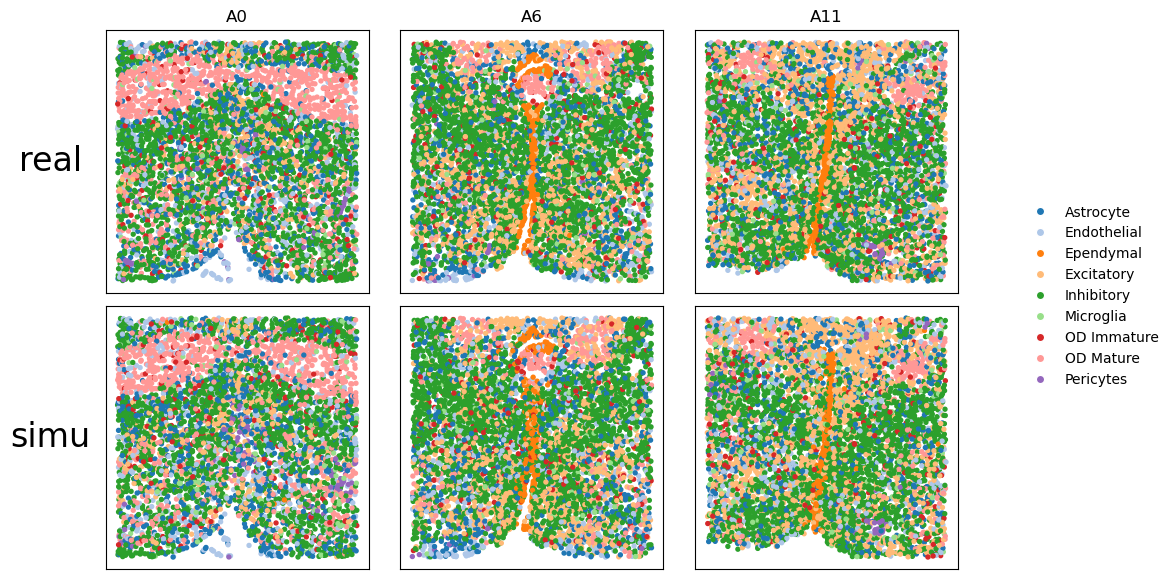

In [12]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

slices = ["A0", "A6", "A11"]

# -----------------------------
# Fix the cell-type order
# -----------------------------
cell_order = sorted(adata.obs["cell_type"].unique())

# color
cmap = plt.get_cmap("tab20")
colors = {ct: cmap(i) for i, ct in enumerate(cell_order)}

# -----------------------------
# Create the figure
# -----------------------------
fig, axes = plt.subplots(
    2, len(slices),
    figsize=(12,7)
)

for i, s in enumerate(slices):

    ad = adata[adata.obs["batch"] == s]

    x = ad.obsm["spatial_3d"][:,0]
    y = ad.obsm["spatial_3d"][:,1]

    # ---------------- Real ----------------
    real_colors = [colors[c] for c in ad.obs["cell_type"]]

    axes[0,i].scatter(
        x, y,
        c=real_colors,
        s=8
    )

    axes[0,i].set_title(s)
    axes[0,i].set_xticks([])
    axes[0,i].set_yticks([])
    axes[0,i].set_aspect("equal")

    # ---------------- Sim ----------------
    sim_colors = [colors[c] for c in ad.obs["pred_celltype"]]

    axes[1,i].scatter(
        x, y,
        c=sim_colors,
        s=8
    )

    axes[1,i].set_xticks([])
    axes[1,i].set_yticks([])
    axes[1,i].set_aspect("equal")

# -----------------------------
# Labels on the left
# -----------------------------
axes[0,0].set_ylabel("real", fontsize=24, rotation=0, labelpad=40, va="center")
axes[1,0].set_ylabel("simu", fontsize=24, rotation=0, labelpad=40, va="center")

# -----------------------------
# legend
# -----------------------------
handles = [
    plt.Line2D(
        [0],[0],
        marker="o",
        color="w",
        markerfacecolor=colors[ct],
        markersize=6,
        label=ct
    )
    for ct in cell_order
]

fig.legend(
    handles=handles,
    loc="center right",
    bbox_to_anchor=(1.02,0.5),
    frameon=False
)

# -----------------------------
# Adjust the spacing
# -----------------------------
plt.subplots_adjust(
    wspace=0.05,
    hspace=0.05,
    right=0.85
)

plt.savefig(
    "cell_type/celltype_compare_all.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()



In [13]:
adata.write_h5ad("../adata_backup_with_pred_region_celltype.h5ad")
